# Week 6 — EDA II: relationships + hypothesis drafting

### Deliverable
- 4 relationship plots + 2 hypotheses in H0/H1 form


In [1]:
# Core imports (kept minimal for beginners)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Dataset URL (UCI Heart Disease - Cleveland)
UCI_URL = "https://www.archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for processed.cleveland.data (14 columns commonly used in teaching)
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","num"]


In [2]:
import ssl
import io
import urllib.request # Added this import

def load_raw():
    # Create an unverified SSL context to bypass certificate verification
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    # Open the URL with the unverified context
    with urllib.request.urlopen(UCI_URL, context=ctx) as url_response:
        # Read the content and decode it
        s = url_response.read().decode('utf-8')

    # Use io.StringIO to make the string behave like a file for pandas.read_csv
    df_raw = pd.read_csv(io.StringIO(s), header=None, names=COLS)
    return df_raw

def coerce_types(df_raw):
    # Missing values are sometimes encoded as "?"
    df = df_raw.replace("?", np.nan).copy()

    # Convert numeric-looking columns
    numeric_cols = ["age","trestbps","chol","thalach","oldpeak","ca","thal","num"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Binary target: disease present if num > 0 (UCI convention)
    df["disease"] = (df["num"] > 0).astype("Int64")
    return df

df_raw = load_raw()
df = coerce_types(df_raw)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
def clean_heart(df_raw):
    df = df_raw.replace("?", np.nan).copy()
    numeric_cols = ["age","trestbps","chol","thalach","oldpeak","ca","thal","num"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["disease"] = (df["num"] > 0).astype("Int64")
    return df.dropna(subset=["disease"])

df_clean = clean_heart(df_raw)


## Plot A — Numeric vs disease


/tmp/ipykernel_12327/3740564177.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["no disease","disease"])


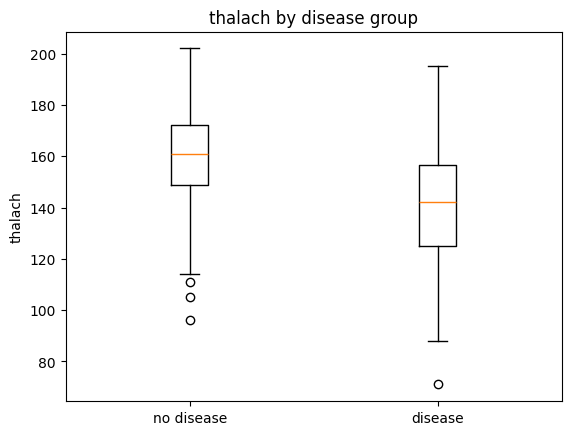

Counts: 164 139


In [4]:
col = "thalach"  # TODO
g0 = df_clean.loc[df_clean["disease"]==0, col].dropna()
g1 = df_clean.loc[df_clean["disease"]==1, col].dropna()

plt.figure()
plt.boxplot([g0, g1], labels=["no disease","disease"])
plt.ylabel(col)
plt.title(f"{col} by disease group")
plt.show()

print("Counts:", len(g0), len(g1))


## Plot B — Categorical vs disease


disease,0,1
cp,,
1.0,16,7
2.0,41,9
3.0,68,18
4.0,39,105


<Figure size 640x480 with 0 Axes>

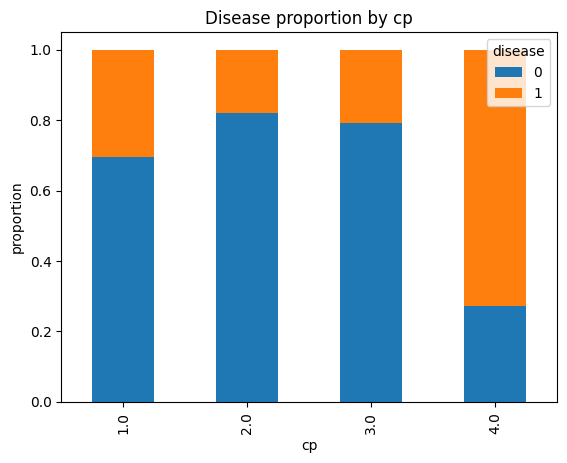

In [5]:
cat = "cp"  # TODO
ct = pd.crosstab(df_clean[cat], df_clean["disease"], dropna=False)
display(ct)

props = ct.div(ct.sum(axis=1), axis=0)
plt.figure()
props.plot(kind="bar", stacked=True)
plt.ylabel("proportion")
plt.title(f"Disease proportion by {cat}")
plt.show()


## Plot C — Numeric vs numeric (colored by disease)


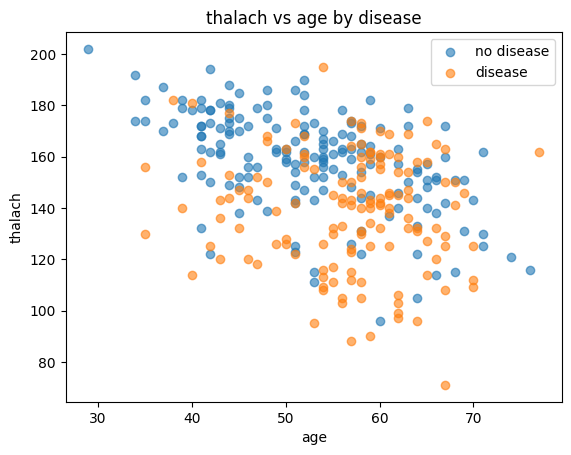

In [6]:
xcol, ycol = "age", "thalach"  # TODO
d0 = df_clean[df_clean["disease"]==0]
d1 = df_clean[df_clean["disease"]==1]

plt.figure()
plt.scatter(d0[xcol], d0[ycol], alpha=0.6, label="no disease")
plt.scatter(d1[xcol], d1[ycol], alpha=0.6, label="disease")
plt.xlabel(xcol); plt.ylabel(ycol)
plt.title(f"{ycol} vs {xcol} by disease")
plt.legend()
plt.show()


## Plot D — Stratified view (probe confounding)


/tmp/ipykernel_12327/3965573756.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["no disease","disease"])


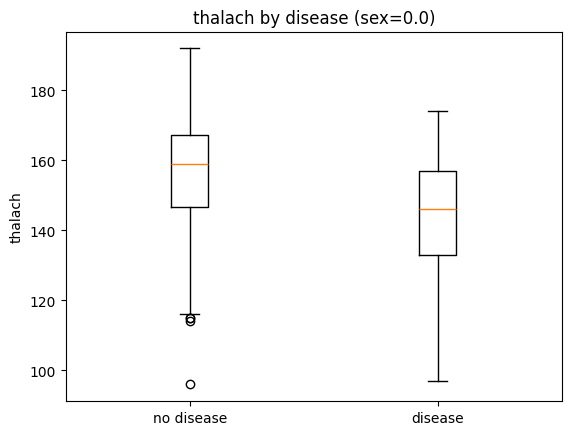

/tmp/ipykernel_12327/3965573756.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["no disease","disease"])


sex= 0.0 counts: 72 25


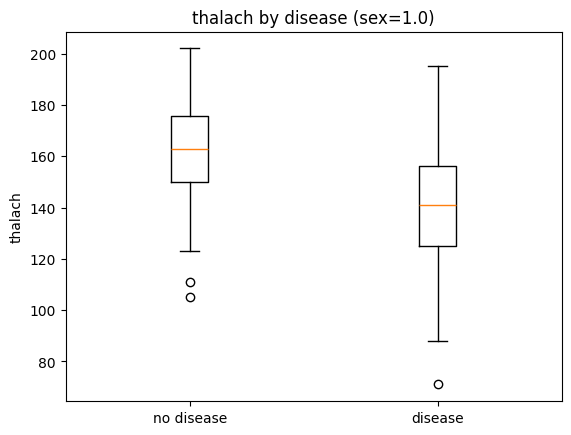

sex= 1.0 counts: 92 114


In [7]:
col = "thalach"
for sex_code in sorted(df_clean["sex"].dropna().unique()):
    sub = df_clean[df_clean["sex"]==sex_code]
    g0 = sub.loc[sub["disease"]==0, col].dropna()
    g1 = sub.loc[sub["disease"]==1, col].dropna()

    plt.figure()
    plt.boxplot([g0, g1], labels=["no disease","disease"])
    plt.ylabel(col)
    plt.title(f"{col} by disease (sex={sex_code})")
    plt.show()

    print("sex=", sex_code, "counts:", len(g0), len(g1))


## TODO — Two hypotheses (H0/H1)
Hypothesis 1: Max heart rate and heart disease
- H0: The mean maximum heart rate (thalach) is equal between patients with
  heart disease and patients without heart disease.
  μ(thalach | disease=1) = μ(thalach | disease=0)

- H1: Patients with heart disease have a significantly lower mean maximum
  heart rate than patients without heart disease.
  μ(thalach | disease=1) < μ(thalach | disease=0)

- Planned test: Independent-samples t-test (one-tailed). Check normality
  with a histogram or Shapiro-Wilk test first; if violated, use Mann-Whitney U
  as a non-parametric alternative.


Hypothesis 2: Chest pain type and heart disease
- H0:  The proportion of patients with heart disease is the same across all
  four chest pain types (cp = 1, 2, 3, 4).
   P(disease | cp=1) = P(disease | cp=2) = P(disease | cp=3) = P(disease | cp=4)
- H1: At least one chest pain type has a significantly different proportion
  of heart disease compared to the others.
  not all proportions are equal
- Planned test: Chi-square test of independence on the contingency table
  of cp × disease. If any expected cell count is < 5, use Fisher's exact test
  instead.
